**Урок 3.**

**Задача 1.** Робота з зображеннями як з матрицями.

Дано матрицю зображення $M$ та матрицю накладеного ефекту $E$:

\
\begin{aligned}
M &= \begin{pmatrix}
100 & 150 & 200\\
50  & 100 & 150\\
0   & 50  & 100
\end{pmatrix}\\[6pt]
E &= \begin{pmatrix}
20 & 10 & 5\\
30 & 20 & 10\\
40 & 30 & 15
\end{pmatrix}
\end{aligned}


Необхідно реалізувати три алгоритми обробки:

1. Зміна контрасту.
Необхідно зменшити яскравість зображення
$M$. Це множення матриці на скаляр (число)
$λ$. Кожен елемент матриці множиться на це число 0.5


In [ ]:
import numpy as np

m = np.array([
    [100, 150, 200],
    [ 50, 100, 150],
    [  0,  50, 100]
], dtype=float)
m

array([[100., 150., 200.],
       [ 50., 100., 150.],
       [  0.,  50., 100.]])

In [ ]:
e = np.array([
    [20, 30, 40],
    [10, 20, 30],
    [ 5, 10, 15]
], dtype=float)
e

array([[20., 30., 40.],
       [10., 20., 30.],
       [ 5., 10., 15.]])

In [ ]:
print("1. Зміна контрасту (0.5 * m):")
print(contrast)

1) Зміна контрасту (0.5 * m):
[[ 50.  75. 100.]
 [ 25.  50.  75.]
 [  0.  25.  50.]]


2. Корекція яскравості. Це додавання скаляра
**c** до матриці
$m$. Число додається до кожного елемента матриці. Додайте до зображення
$m$ число 25. Це збільшить яскравість кожного пікселя на 25.

In [ ]:
brightness = m + 25
print("2. Корекція яскравості (m + 25):")
print(brightness)

2. Корекція яскравості (m + 25):
[[125. 175. 225.]
 [ 75. 125. 175.]
 [ 25.  75. 125.]]


3. Змішування (Blending). Ми створюємо нове зображення, змішуючи оригінал та ефект у певній пропорції. Для цього створи нове зображення як лінійну комбінацію: 0.8⋅M+0.2⋅E. Це імітує прозорість ефекту.

In [ ]:
blend = 0.8 * m + 0.2 * e
print("3. Змішування (0.8*m + 0.2*e):")
print(blend)

3. Змішування (0.8*m + 0.2*e):
[[ 84. 126. 168.]
 [ 42.  84. 126.]
 [  1.  42.  83.]]


**Висновок.**

Зменшення контрасту реалізовано множенням усіх пікселів на 0.5, що знижує їхню яскравість у 2 рази. Корекція яскравості виконана додаванням 25 до кожного елемента, що рівномірно підсвічує зображення. Змішування реалізовано як лінійну комбінацію 0.8·M + 0.2·E, що додає ефект із частковою прозорістю.

**Задача 2.**
Пошук схожих фільмів

Є профіль користувача — це вектор інтересів до жанрів [Екшн, Комедія, Драма].



Також є три фільми A, B, C, кожен з яких має таку ж структуру характеристик.

Вектор профілю користувача: u = (8, 2, 5)

Та три фільмів.

Фільм A (Action Movie): v_A = (9, 1, 2)

Фільм B (Comedy Movie): v_B = (1, 9, 8)

Фільм C (Drama Movie): v_C = (7, 2, 6)


Задача — знайти фільм, який найбільше підходить користувачу, порівнявши вектори їхніх характеристик.

1. Створіть вектор профілю користувача та вектори фільмів.

In [ ]:
# Вектор профілю користувача
user = np.array([8, 2, 5], dtype=float)
user

array([8., 2., 5.])

In [ ]:
# Вектори фільмів
movies = {
    "A (Action Movie)": np.array([9, 1, 2], dtype=float),
    "B (Comedy Movie)": np.array([1, 9, 8], dtype=float),
    "C (Drama Movie)": np.array([7, 2, 6], dtype=float),
}

movies

{'A (Action Movie)': array([9., 1., 2.]),
 'B (Comedy Movie)': array([1., 9., 8.]),
 'C (Drama Movie)': array([7., 2., 6.])}

2. Реалізуйте функцію косинусної схожості за формулою

In [ ]:
# Реалізація формули косинусної схожості
def cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)    # Скалярний добуток

    norm_v1 = np.linalg.norm(v1)    # Довжини векторів (норми)
    norm_v2 = np.linalg.norm(v2)
    # Формула
    return dot_product / (norm_v1 * norm_v2)

3. Обчисліть схожість для кожного фільму.
4. Виведіть на екран коефіцієнти схожості для кожного фільму та назву фільму, вектор якого має найбільше значення косинусної подібності.

In [ ]:
# Обчислення та пошук найкращого курсу
best_movie = ""
max_score = -1.0  # Початкове значення (мінімально можливе)

print("--- Результати схожості ---")
for name, movie_vec in movies.items():
    score = cosine_similarity(user, movie_vec)
    print(f"{name}: {score:.4f}")
    # Перевірка на максимум
    if score > max_score:
        max_score = score
        best_movie = name

# Вивід найкращого фільма
print("\n--- Рекомендація ---")
print(f"Вам найбільше підходить фільм: {best_movie}")

--- Результати схожості ---
A (Action Movie): 0.9393
B (Comedy Movie): 0.5664
C (Drama Movie): 0.9892

--- Рекомендація ---
Вам найбільше підходить фільм: C (Drama Movie)


5. Перевірте себе та порівняйте з аналітичними обчисленнями, щоб вони збігалися

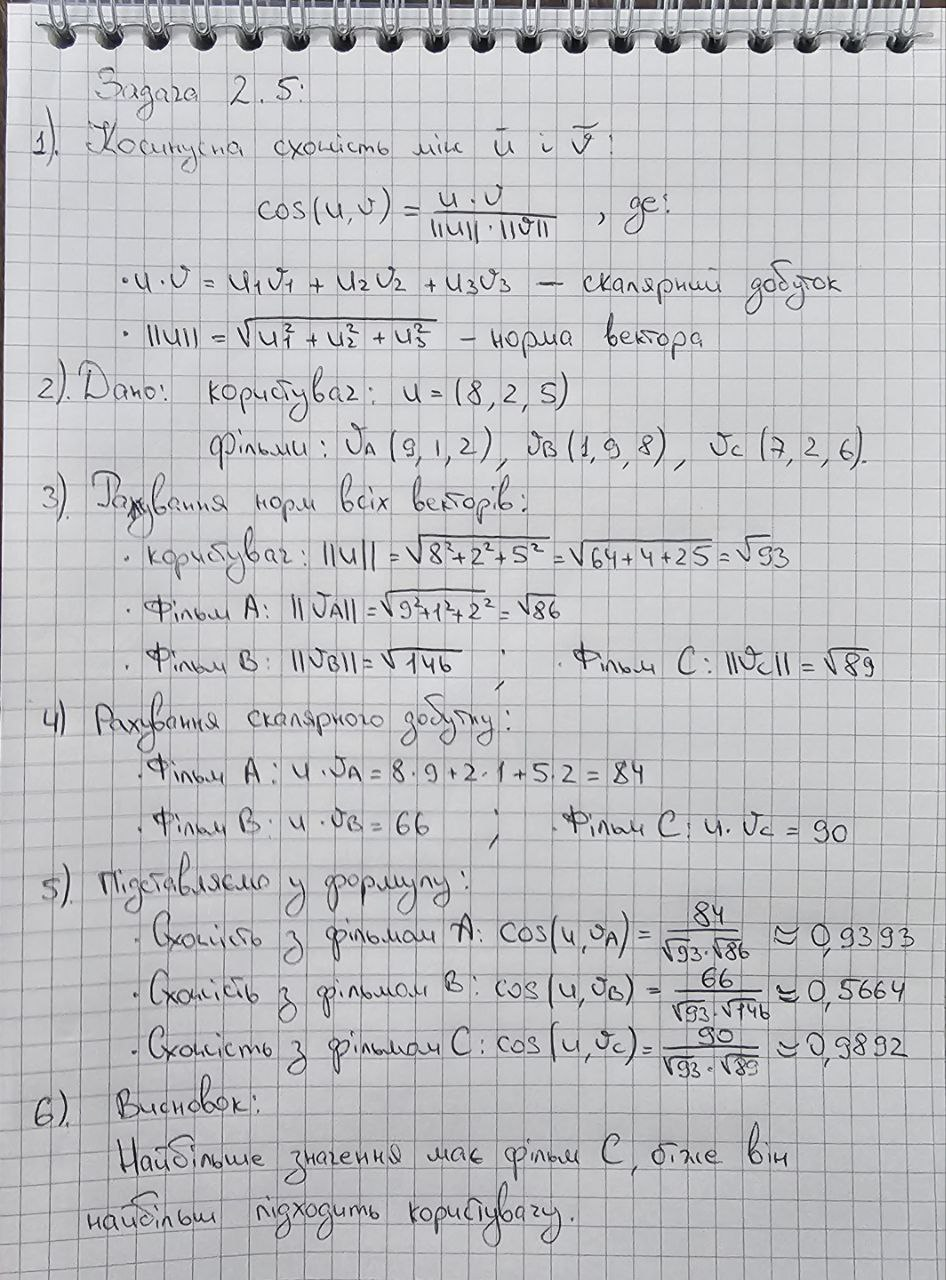

**Висновок.**

Ми порівняли профіль користувача $u=(8,2,5)$ з векторами фільмів за допомогою косинусної схожості:
$$
\mathrm{similarity}(u,v)=\frac{u\cdot v}{\|u\|\|v\|}.
$$
Отримані значення показують, наскільки близькі напрямки векторів, тобто наскільки жанровий «профіль» фільму відповідає інтересам користувача незалежно від довжини векторів.  
Найбільшу косинусну схожість має фільм **C**, отже саме він є найкращою рекомендацією.  
Значення схожості лежить у діапазоні від $-1$ до $1$: чим ближче до $1$, тим сильніше збігаються вподобання користувача та характеристики фільму.



**Задача 3**. Аналіз виробництва

Цех зі збірки FPV-дронів.

Є три моделі:
*   "Розвідник" x1;
*   "Камікадзе" x2;
*   "Вантажний" дрон x3.

Кожен із них потребує різного набору комплектуючих:
*   моторів;
*   польотних контролерів;
*   акумуляторів.

В кінці зміни приходить звіт про загальні витрати деталей, але через збій у системі втратили дані про те, скільки саме дронів кожного типу було зібрано.

Задача на відновлення даних, яка вирішується через систему лінійних рівнянь
Ax = b.

Відомі витрати на один дрон, це матриця $a$, де стовпці — це типи дронів:
*   "Розвідник": 4 мотори, 1 контролер, 1 акумулятор.
*   "Камікадзе": 4 мотори, 1 контролер, 2 акумулятори.
*   "Вантажний": 6 моторів, 2 контролери, 4 акумулятори.

Всього за зміну було витрачено вектор $b$:
*   460 моторів
*   130 контролерів
*   240 акумуляторів


Використовуючи бібліотеку numpy, напишіть програму та виконайте наступні кроки:

1. Сформуйте матрицю коефіцієнтів A та вектор вільних членів b.

In [ ]:
# 1. Вхідні дані
# Стовпці: Розвідник, Камікадзе, Вантажний
# Рядки: мотори, контролери, акумулятори
import numpy as np
a = np.array([
    [4, 4, 6],
    [1, 1, 2],
    [1, 2, 4]
])
a

array([[4, 4, 6],
       [1, 1, 2],
       [1, 2, 4]])

In [ ]:
# Витрачено за зміну:
b = np.array([460, 130, 240])
b

array([460, 130, 240])

2. Перед розв'язанням перевірте, чи має система єдиний розв'язок. Для цього обчисліть визначник матриці $a$ за допомогою функції np.linalg.det(A). Якщо він не дорівнює нулю — розв'язок існує.
3. Розв'яжіть систему за допомогою np.linalg.solve(A, b) і знайдіть вектор
$x$. Це буде кількість зібраних дронів кожного типу.
4. Виконайте перевірку правильності розрахунків: перемножте матрицю
$a$ на знайдений вектор $x$. Результат має збагатися з вектором $b$.
5. Виведіть кількість дронів кожного типу та результати перевірки.

In [ ]:
# 2. Перевірка визначника
det = np.linalg.det(a)
print(f"Визначник матриці: {det:.2f}")

if abs(det) < 1e-9:
    print("Система не має єдиного розв'язку")
else:
    # 3. Розв'язання системи
    x = np.linalg.solve(a, b)

    print("--- Звіт віробництва ---")
    print(f"Розвідник: {x[0]:.0f}")
    print(f"Камікадзе: {x[1]:.0f}")
    print(f"Вантажний: {x[2]:.0f}")

    # 4. Матричний метод
    check = a @ x
    print("\n--- Перевірка деталей ---")
    print(f"Розрахунок: {check}")
    print(f"Фактично:   {b}")

Визначник матриці: -2.00
--- Звіт продажів ---
Розвідник: 20
Камікадзе: 50
Вантажний: 30

--- Перевірка деталей ---
Розрахунок: [460. 130. 240.]
Фактично:   [460 130 240]


**Висновок.**

У цій задачі виробництво дронів було змодельовано як система лінійних рівнянь (A x = b), де $a$ описує витрати деталей на один дрон, а $b$ — загальні витрати за зміну. Перевірка визначника показала, що система має єдиний розв’язок. За допомогою np.linalg.solve знайдено кількість зібраних дронів кожного типу. Правильність результату підтверджено перевіркою множенням a*x, яке повністю збігається з вектором $b$.


**Задача 4.**

Прогноз тренду.

При моніторингу IT-інфраструктури дані часто надходять із шумом. Навантаження на CPU сервера може коливатися, але загальний тренд вказує на поступове зростання. Щоб передбачити, коли сервер досягне критичного навантаження, потрібно побудувати лінію тренду (y = kx + b). Оскільки точки не лежать ідеально на одній прямій, точного розв’язку системи не існує, тому використовується метод найменших квадратів (МНК).

Дано виміри завантаження CPU (y) протягом 5 годин (t):

* Час: (t = [1, 2, 3, 4, 5])
* Навантаження: (y = [22, 28, 37, 45, 53])

**Використовуючи бібліотеку NumPy, виконайте кроки:**

1. Сформуйте матрицю $a$. Для знаходження вільного члена $b$ матриця повинна містити стовпчик зі значень $t$ та стовпчик з одиниць.

In [ ]:
# Вхідні дані
import numpy as np
t = np.array([1, 2, 3, 4, 5], dtype=float)
t

array([1., 2., 3., 4., 5.])

In [ ]:
y = np.array([22, 28, 37, 45, 53], dtype=float)
y

array([22., 28., 37., 45., 53.])

In [ ]:
# Формування матриці A: [t, 1]
a = np.column_stack((t, np.ones_like(t)))
a

array([[1., 1.],
       [2., 1.],
       [3., 1.],
       [4., 1.],
       [5., 1.]])

2. Знайдіть коефіцієнти прямої $k$ та $b$ за допомогою функції `np.linalg.lstsq(A, y)`. Ця функція повертає найкращий наближений розв’язок.


In [ ]:
# 3. Пошук рішення МНК (метод найменших квадратів)
solution, residuals, rank, s = np.linalg.lstsq(a, y)
k, b = solution

print("\n--- Результати МНК ---")
print(f"Коефіцієнт k = {k:.1f}")
print(f"Вільний член b = {b:.1f}")
print(f"Рівняння тренду: y = {k:.1f}x + {b:.1f}")


--- Результати МНК ---
Коефіцієнт k = 7.9
Вільний член b = 13.3
Рівняння тренду: y = 7.9x + 13.3


3. Використовуючи знайдені коефіцієнти, обчисліть прогнозоване навантаження на 6-ту годину за формулою $\hat{y} = k \cdot 6 + b.$

4. Виведіть рівняння отриманого тренду та прогноз.


In [ ]:
# Прогноз на 6-ту годину
t_6 = 6
y_6 = k * t_6 + b
print(f"\nПрогноз на {t_6}-ту годину: {y_6:.1f}% CPU")


Прогноз на 6-ту годину: 60.7% CPU


**Опціональне завдання:**

Функція `np.linalg.lstsq()` використовує нормальне рівняння для знаходження оптимальних коефіцієнтів.

Знайдіть коефіцієнти $k$ — нахил, та $b$ — зсув через нормальне рівняння $A^T A x = A^T y$.

Де $x = [k,\, b]^T$ — вектор невідомих коефіцієнтів.

1. Обчислити $A^TA$:

In [ ]:
AT = a.T
ATA = AT @ a
print("A^T A =\n", ATA)

A^T A =
 [[55. 15.]
 [15.  5.]]


2. Обчислити $A^Ty$:

In [ ]:
ATy = AT @ y       # A^T y
print("\nA^T y =", ATy)


A^T y = [634. 185.]


3. Розв'яжіть систему через `np.linalg.solve()`.

In [ ]:
x = np.linalg.solve(ATA, ATy)
k, b = x
print("\n[k, b] =", x)
print(f"k = {k:.4f}, b = {b:.4f}")


[k, b] = [ 7.9 13.3]
k = 7.9000, b = 13.3000


4. Порівняйте результат з `np.linalg.lstsq` — вони мають збігатися

In [ ]:
sol_lstsq, residuals, rank, s = np.linalg.lstsq(a, y, rcond=None)
k2, b2 = sol_lstsq

print("\n--- Порівняння ---")
print(f"normal eq: k={k:.6f}, b={b:.6f}")
print(f"lstsq:     k={k2:.6f}, b={b2:.6f}")

print("\nРізниця (normal - lstsq):")
print(f"Δk = {k - k2:.12f}")
print(f"Δb = {b - b2:.12f}")


--- Порівняння ---
normal eq: k=7.900000, b=13.300000
lstsq:     k=7.900000, b=13.300000

Різниця (normal - lstsq):
Δk = 0.000000000000
Δb = 0.000000000000


**Висновок.**

Коефіцієнти $k$ та $b$, знайдені через нормальне рівняння $A^T A x = A^T y$, збігаються з результатом функції `np.linalg.lstsq()`. Це означає, що обидва методи знаходять один і той самий розв’язок МНК для даних вимірювань. Різниця між значеннями може бути лише дуже малою через похибки обчислень з плаваючою комою. Отже, реалізація методу нормальних рівнянь виконана правильно.
